1. nn means neural network layers such as linear, ReLU.
2. optim means optimization functions like adam
3. torchvision uses image data for input
4. DataLoader loads data

In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

1. torch.cuda.is_available() is to check whether current system utilises CPU or GPU

In [ ]:
# 1. Device (CPU / GPU)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# 2. Load Dataset

transform = transforms.ToTensor()

train_data = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.0MB/s]


In [ ]:
test_data = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

In [ ]:
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

In [ ]:
len(train_loader) ###60000 / 64 ≈ 938 batches

938

In [ ]:
len(test_loader) ### 10000 / 64 = 157 batches

157

In [ ]:
images, labels = next(iter(train_loader))

In [ ]:
labels.shape

torch.Size([64])

In [ ]:
labels

tensor([0, 5, 0, 8, 3, 9, 0, 5, 8, 9, 2, 8, 4, 8, 3, 9, 3, 0, 3, 5, 7, 1, 6, 9,
        9, 3, 0, 3, 2, 2, 3, 0, 5, 3, 2, 6, 6, 9, 9, 8, 8, 0, 1, 1, 9, 9, 0, 0,
        1, 6, 9, 4, 3, 5, 9, 8, 4, 8, 8, 6, 6, 5, 0, 9])

In [ ]:
images.shape ##[64, 1, 28, 28] means [Batch Size, Channels, Height, Width] channel = 1 (greyscale) and channel = 3 (RGB)

torch.Size([64, 1, 28, 28])

In [ ]:
# 3. Model (3 Hidden Layers)

class ANN(nn.Module):  ## we are defining our own neural network
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(       ## pipeline as layers start
            nn.Flatten(),          # 28x28 → 784 ##[64, 784]
             ##why flatten? if we will not use then your input behaves like pixels and network will not understand
            nn.Linear(784, 256), #input 784 features and output 256 neurons
            nn.ReLU(),

            nn.Linear(256, 128), ## reduces dimensions learns deeper patterns
            nn.ReLU(),

             nn.Linear(128, 64), ## more reduced
            nn.ReLU(),

            nn.Linear(64, 10)      # 10 classes #output 10 values one for each class
        )

    def forward(self, x):
        return self.model(x)

model = ANN().to(device) #model is created

In [ ]:
# 4. Loss & Optimizer

criterion = nn.CrossEntropyLoss() ## used for multi class classification ##applies softmax as this is multi class
optimizer = optim.Adam(model.parameters(), lr=0.001) #adam optimizer

In [ ]:
# 5. Training

epochs = 5

for epoch in range(epochs):
    model.train() #training starts
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

         # Forward
        outputs = model(images)
        loss = criterion(outputs, labels) #compares actual vs predicted

        # Backward
        optimizer.zero_grad() ##clears old gradients
        loss.backward() ##gradient calculations happens
        optimizer.step() ##adjusts weights

        total_loss += loss.item() ##losses keep on adding

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss:.4f}")

Epoch [1/5], Loss: 527.1964
Epoch [2/5], Loss: 358.4603
Epoch [3/5], Loss: 318.9910
Epoch [4/5], Loss: 294.7247
Epoch [5/5], Loss: 278.4726


In [ ]:
# 6. Evaluation

model.eval() ##switch to evaluation mode
correct = 0
total = 0

with torch.no_grad(): ##gradient calculation turns off
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)  ##get predictions
        _, predicted = torch.max(outputs, 1) ##picks class with highest score

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")
print(correct)  ##Counts correct predictions
print(total)

Test Accuracy: 0.8764
8764
10000


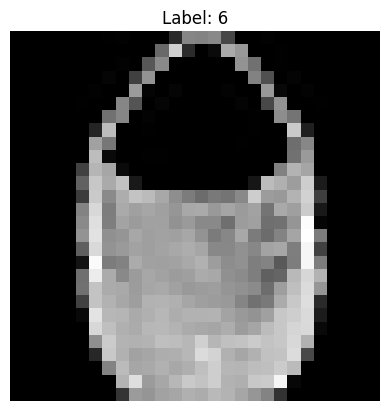

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[20].item()}")
plt.axis('off')
plt.show()